# Comparison of the HHL to the Thomas for various different Forcing functions, Wave Numbers in 1D and 2D

## To - do:
1. 1D sin function, dirchlet b-c's, small wave number, 2x2 #
2. 1D sin function, dirchlet b-c's, small wave number, 4x4 #
3. 1D sin function, dirchlet b-c's, small wave number, 8x8 #
4. 1D sin function, dirchlet b-c's, large wave number, 4x4 #

5. 1D sin function, dirchlet + neumann b-c's, small wave number, 4x4
6. 1D sin function, robin b-c's, small wave number, 4x4


7. 1D step function, dirchlet b-c's, small wave number, 4x4
8. 1D step function, dirchlet b-c's, small wave number, 8x8
9. 1D step function, dirchlet b-c's, large wave number, 4x4

10. 1D impulse function, dirchlet b-c's, small wave number, 4x4
11. 1D impulse function, dirchlet b-c's, small wave number, 8x8
12. 1D impulse function, dirchlet b-c's, large wave number, 4x4

*Maybe*: 
Varying wave numbers i.e. k is a funciton of domain
Complex grid domains i.e. cavities, obstacles

Import necessary modules

In [1]:
# make use of QLS jupyter env
import numpy as np
import scipy as sc
from linear_solvers import NumPyLinearSolver, HHL
import time
from linear_solvers.matrices.tridiagonal_toeplitz import TridiagonalToeplitz
from linear_solvers.matrices.numpy_matrix import NumPyMatrix
from numerical_solvers.thomas_algorithm import numerical_solvers
from qiskit.quantum_info import Statevector
from qiskit import Aer, transpile
from scipy.sparse import diags
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def normalize(arr, t_min, t_max):
    """
    Normalize an array to a specified range [t_min, t_max].
    
    For data that spans both negative and positive values, this function
    uses a symmetric normalization (dividing by the maximum absolute value)
    to preserve the zero-crossing and the relative oscillatory behavior.
    
    For data that does not span both signs, it uses standard min-max normalization.
    """
    arr = np.array(arr)
    # Check if data spans both negative and positive values
    # Use symmetric normalization:
    max_abs = np.max(np.abs(arr))
    # Avoid division by zero
    if max_abs < 1e-12:
        norm_arr = arr.copy()
    else:
        norm_arr = arr / max_abs
    # If the target range is symmetric about zero (e.g., [-1, 1]),
    # then simply scale by the maximum absolute value.
    # Otherwise, map [-1, 1] to [t_min, t_max]:
    if t_min == -1 and t_max == 1:
        return norm_arr
    else:
        # Mapping from [-1,1] to [t_min, t_max]:
        return ((norm_arr + 1) / 2) * (t_max - t_min) + t_min
    
    
def get_solution_vector(solution, N, vector):
    """Extracts and normalizes simulated state vector from LinearSolverResult."""
    start = 2**(N-1)
    fin = 2**(N-1) + len(vector)
    solution_vector = Statevector(solution.state).data[start:fin].real
    norm = solution.euclidean_norm
    return norm*solution_vector / np.linalg.norm(solution_vector)


### 1D sin function testing

hello

 Number of ancilla qubits 
:  0

 Number of flag qubits 
:  1

 Number of clock qubits 
:  4

 Number of b qubits 
:  1
hello

 Number of ancilla qubits 
:  1

 Number of flag qubits 
:  1

 Number of clock qubits 
:  6

 Number of b qubits 
:  2
hello

 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  7

 Number of b qubits 
:  3


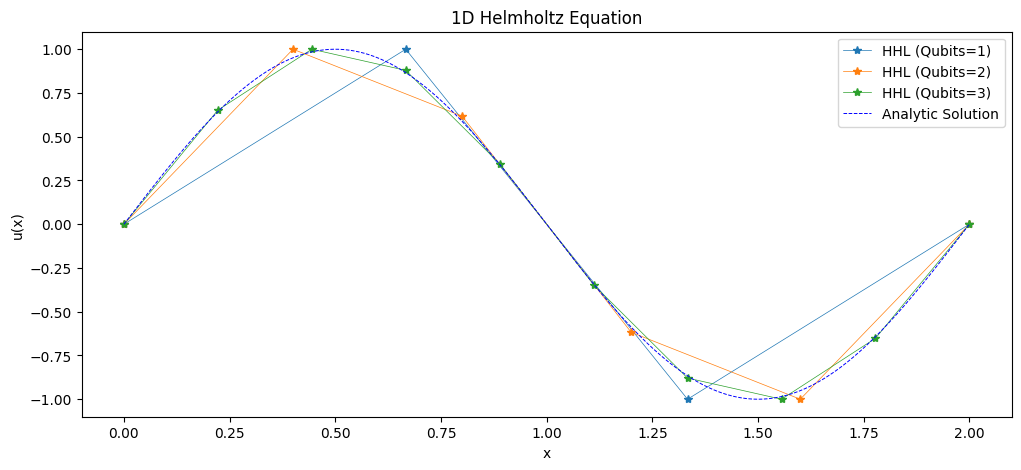

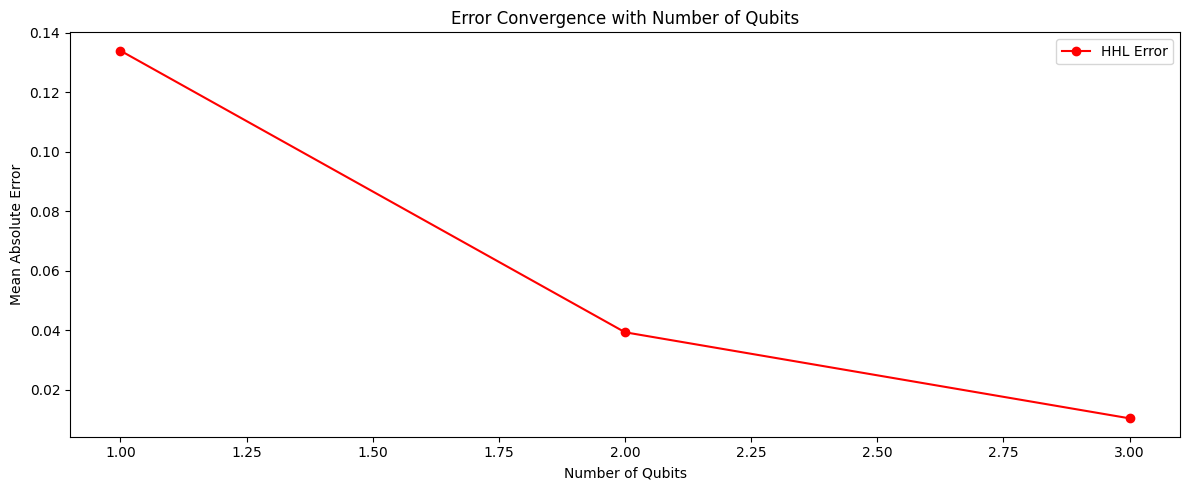

In [46]:
# Build the matrix A
NUM_QUBITS = 3
MATRIX_SIZE = 2 ** NUM_QUBITS
# Define the number of qubits to test
qubit_numbers = [1, 2, 3]

# Initialize lists to store results
errors_hhl = []
errors_thomas = []

# Plot the results for each qubit number on a single graph
plt.figure(figsize=(12, 5))

# Loop over different qubit numbers
for NUM_QUBITS in qubit_numbers:
    MATRIX_SIZE = 2 ** NUM_QUBITS
    L = 2.0                                     # Domain length
    N = MATRIX_SIZE                             # No. of points
    h = L / (N+1)                               # Step size
    k = 1.0                                     # Wavenumber (avoid k = nπ for stability!)
    eps = 0.01                                  # Error tolerance
    x_numerical = np.linspace(0, L, N+2)[1:-1]  # Interior points

    a = -2/h**2 + k**2  # main diagonal
    b = 1/h**2          # off diagonal

    matrix = diags([b, a, b], [-1, 0, 1], shape=(MATRIX_SIZE, MATRIX_SIZE)).toarray()

    vector = (k**2 - np.pi**2) * np.sin(np.pi * x_numerical)

    x_fine = np.linspace(0, L, 1000)  # Fine grid for smooth curve
    u_analytic = np.sin(np.pi * x_fine)
    u_error = np.sin(np.pi * x_numerical)

    # Construct TridiagonalToeplitz matrix circuit with fixed trotter_steps
    tridi_mat = TridiagonalToeplitz(NUM_QUBITS, a, b)

    # Tridiagonal Toeplitz HHL
    tridi_hhl = HHL(epsilon=eps)
    tridi_solution = tridi_hhl.solve(tridi_mat, vector)

    tridi_vector = get_solution_vector(tridi_solution, tridi_solution.state.num_qubits, vector)
    tridi_vector = np.concatenate(([0], tridi_vector, [0]))
    tridi_vector = normalize(tridi_vector, -1, 1)

    mae_hhl = np.mean(np.abs(tridi_vector[1:len(tridi_vector)-1] - u_error))
    errors_hhl.append(mae_hhl)

    # Compare to thomas
    thomas = numerical_solvers()
    num_solution = thomas.solve_tridiagonal_thomas(matrix, vector)
    num_solution = np.concatenate(([0], num_solution, [0]))
    num_solution = normalize(num_solution, -1, 1)

    mae_thomas = np.mean(np.abs(num_solution[1:len(num_solution)-1] - u_error))
    errors_thomas.append(mae_thomas)

    # Plot the results for each qubit number
    #plt.plot(np.concatenate(([0], x_numerical, [L])), num_solution, '*-', linewidth=0.7, label=f'Thomas Algorithm (Qubits={NUM_QUBITS})')
    plt.plot(np.concatenate(([0], x_numerical, [L])), tridi_vector, '*-', linewidth=0.5, label=f'HHL (Qubits={NUM_QUBITS})')

# Plot the analytic solution
plt.plot(x_fine, u_analytic, 'b--', linewidth=0.7, label='Analytic Solution')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('1D Helmholtz Equation')
plt.legend()

# Plot the error convergence
plt.figure(figsize=(12, 5))
plt.plot(qubit_numbers, errors_hhl, 'ro-', label='HHL Error')
#plt.plot(qubit_numbers, errors_thomas, 'kx-', label='Thomas Error')
plt.xlabel('Number of Qubits')
plt.ylabel('Mean Absolute Error')
plt.title('Error Convergence with Number of Qubits')
plt.legend()
plt.tight_layout()
plt.show()

### 1D sin function testing 
Perform tests for a large wave number and with thomas algorithm

Vector: [-5.70127181 -8.73485518 -7.68130273 -3.03358337  3.03358337  7.68130273
  8.73485518  5.70127181]
hello

 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  7

 Number of b qubits 
:  3
HHL Mean Absolute Error for N = 0: 0.01036207006366141
[ 0.          0.65270364  1.          0.87938524  0.34729636 -0.34729636
 -0.87938524 -1.         -0.65270364  0.        ]
Thomas Mean Absolute Error for N = {2^3}: 0.01093608294074025


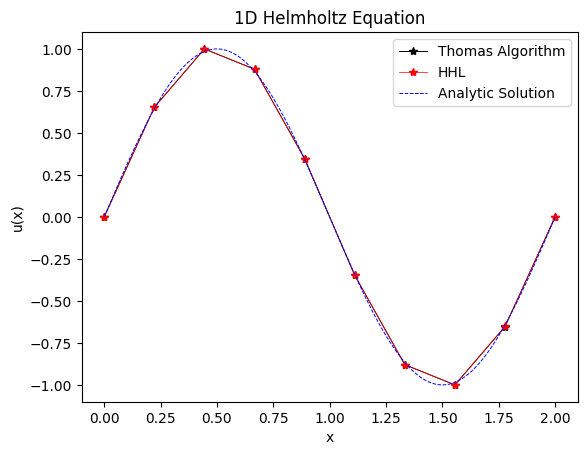

In [38]:
# Build the matrix A
NUM_QUBITS = 3
MATRIX_SIZE = 2 ** NUM_QUBITS

L = 2.0                                     # Domain length
N = MATRIX_SIZE                             # No. of points
h = L / (N+1)                               # Step size
k = 1.0                                    # Wavenumber (avoid k = nπ for stability!)
eps = 0.01                                # Error tolerance
x_numerical = np.linspace(0, L, N+2)[1:-1]  # Interior points


a = -2/h**2 + k**2  # main diagonal
b = 1/h**2          # off diagonal

matrix = diags([b, a, b], [-1, 0, 1], shape=(MATRIX_SIZE, MATRIX_SIZE)).toarray()

vector = ( k**2 - np.pi**2) * np.sin(np.pi * x_numerical) 
print('Vector:', vector)


x_fine = np.linspace(0, L, 1000)  # Fine grid for smooth curve
u_analytic = np.sin(np.pi * x_fine)
u_error = np.sin(np.pi * x_numerical)

# Construct TridiagonalToeplitz matrix circuit with fixed trotter_steps
tridi_mat = TridiagonalToeplitz(NUM_QUBITS, a, b)

# Tridiagonal Toeplitz HHL
tridi_hhl = HHL(epsilon=eps)
tridi_solution = tridi_hhl.solve(tridi_mat, vector)


tridi_vector = get_solution_vector(tridi_solution, tridi_solution.state.num_qubits, vector)
tridi_vector = np.concatenate(([0], tridi_vector, [0]))
tridi_vector = normalize(tridi_vector, -1, 1)

real_domain = np.concatenate(([0], x_numerical, [L]))

mae = np.mean(np.abs(tridi_vector[1:len(tridi_vector)-1] - u_error))
print(f'HHL Mean Absolute Error for N = {2^2}:', mae)

# Compare to thomas
thomas = numerical_solvers()
num_solution = thomas.solve_tridiagonal_thomas(matrix, vector)
num_solution = np.concatenate(([0], num_solution, [0]))
num_solution = normalize(num_solution, -1, 1)
print(num_solution)
# Evaluate the MAE
mae = np.mean(np.abs(num_solution[1:len(num_solution)-1] - u_error))
print('Thomas Mean Absolute Error for N = {2^3}:', mae)

# Create a plot

real_domain = np.concatenate(([0], x_numerical, [L]))

# Plot the results
plt.plot(real_domain, num_solution, 'k*-', linewidth=0.7, label='Thomas Algorithm')
plt.plot(real_domain , tridi_vector, 'r*-' ,linewidth=0.5 ,label='HHL')
# plot analytic solution
plt.plot(x_fine, u_analytic, 'b--', linewidth=0.7, label='Analytic Solution')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('1D Helmholtz Equation')
plt.legend()

Thomas algorithm worse stability than hhl when simulating wave numbers which are close to n*pi, this means that hhl is more stable overall. There is also a no difference in the wave number magnitude when running for different values

### 1D Testing of the Step Forcing function
Evaluating the impact of the step function as an input forcing function as well as the dependence on wave number of the algo.


Testing for wave number k = 0.1
Matrix condition: 32.19536789829443
hello

 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  7

 Number of b qubits 
:  3
Average percent difference between Thomas and HHL solutions: 0.42%

Testing for wave number k = 1.0
Matrix condition: 35.71693398913107
hello

 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  7

 Number of b qubits 
:  3
Average percent difference between Thomas and HHL solutions: 0.15%

Testing for wave number k = 5.0
Matrix condition: 22.419555357285205
hello

 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  6

 Number of b qubits 
:  3
Average percent difference between Thomas and HHL solutions: 13.78%

Testing for wave number k = 10.0
Matrix condition: 11.275273924595648
hello

 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  5

 Number of b qubits 
:  3
Average per

Text(0.5, 1.0, 'Average Percent Difference between Thomas and HHL Solutions')

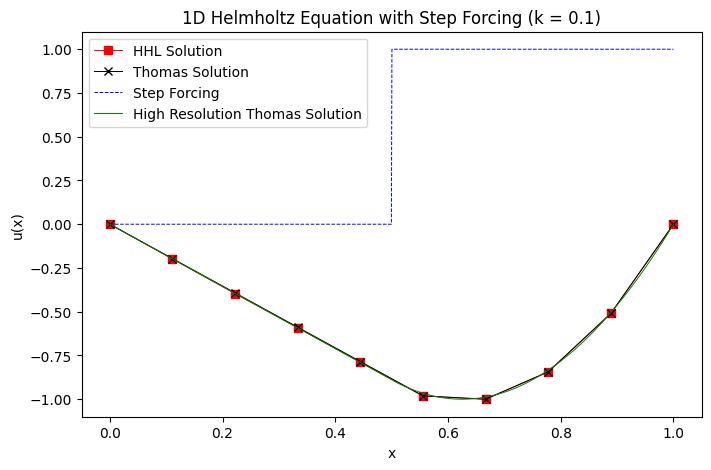

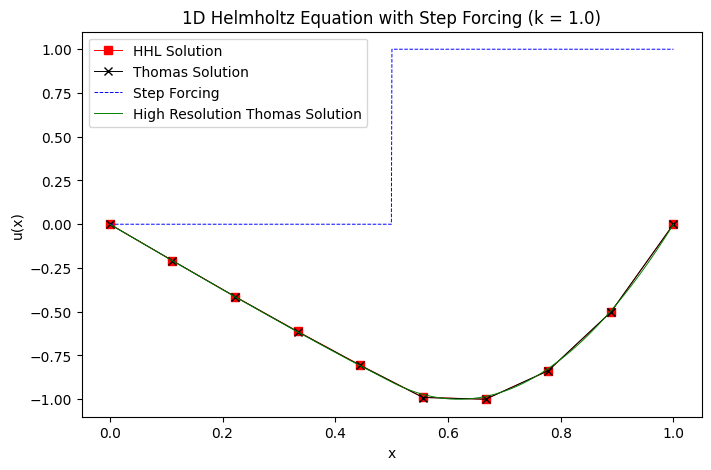

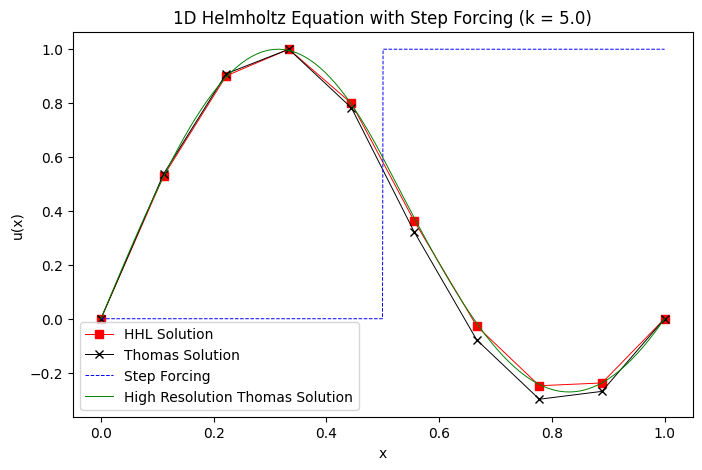

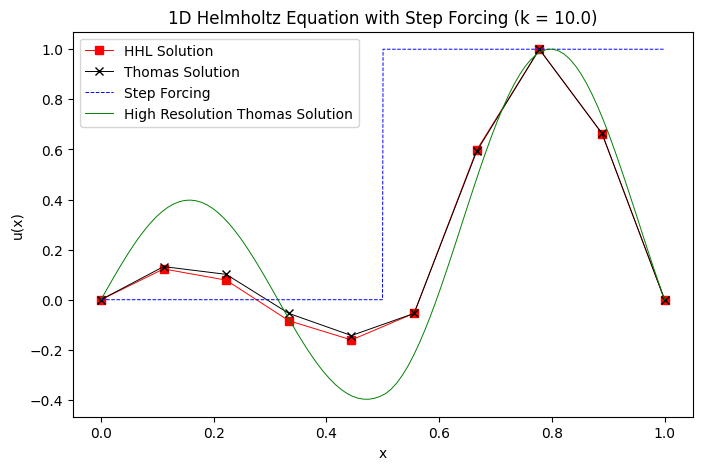

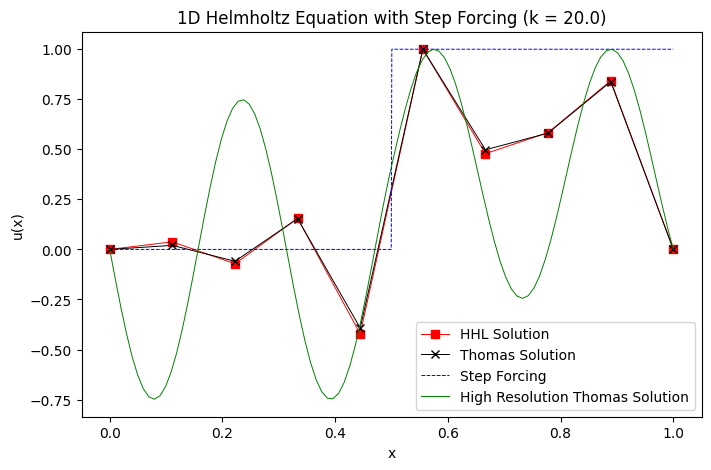

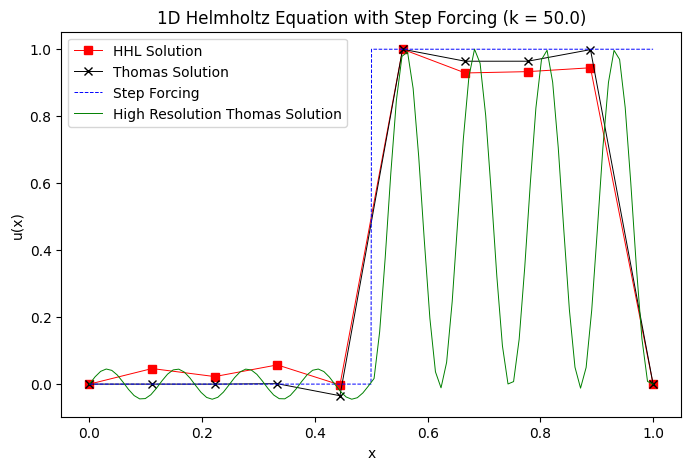

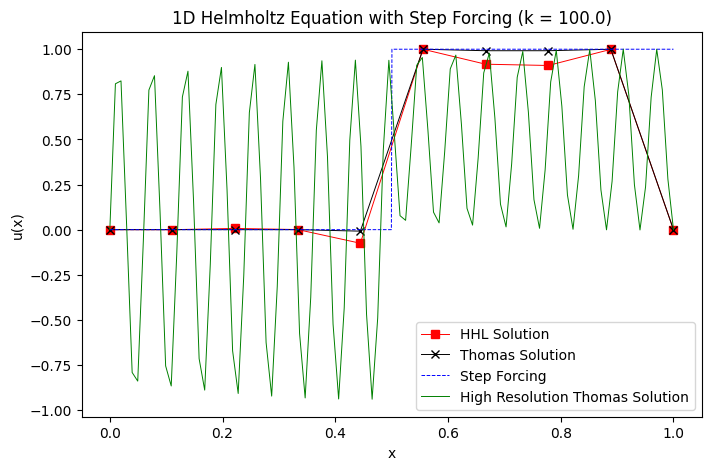

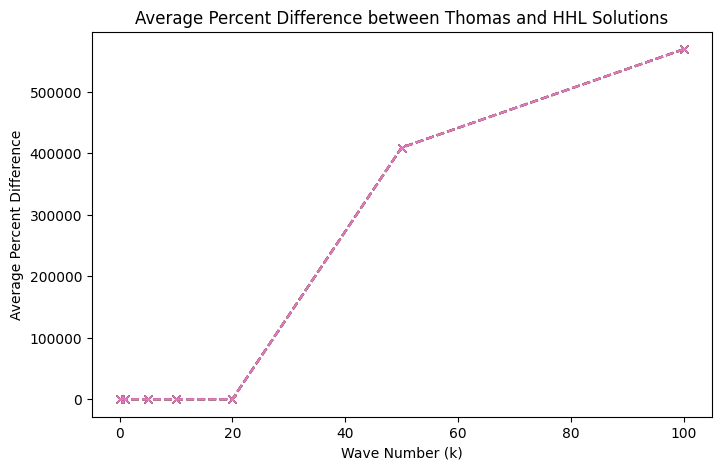

In [53]:

##### NOT WORKING USE THE FUNCTION BELOW
def solve_helmholtz_step(k, num_qubits=3, L=1.0, eps=0.01, plot=True, min_scale=-1, max_scale=1):
    # --- Discretization ---
    MATRIX_SIZE = 2 ** num_qubits  # Number of interior points
    N = MATRIX_SIZE               # For clarity, N is the number of interior points
    h = L / (N + 1)               # Grid spacing

    # Interior grid points (excluding boundaries)
    x_interior = np.linspace(0, L, N + 2)[1:-1]

    # --- Build the Finite-Difference Matrix ---
    a = -2/h**2 + k**2  # main diagonal
    b = 1/h**2          # off-diagonals
    matrix = diags([b, a, b], offsets=[-1, 0, 1], shape=(N, N)).toarray()

    print('Matrix condition:', np.linalg.cond(matrix))

    # --- Define the Step Forcing Term ---
    f = np.where(x_interior < L/2, 0.0, L)

    # --- Solve using HHL ---
    tridi_mat = TridiagonalToeplitz(num_qubits, a, b)
    hhl_solver = HHL(epsilon=eps)
    hhl_solution_obj = hhl_solver.solve(tridi_mat, f)
    hhl_interior = get_solution_vector(hhl_solution_obj, hhl_solution_obj.state.num_qubits, f)
    hhl_vector = np.concatenate(([0], hhl_interior, [0]))
    hhl_sol = normalize(hhl_vector, min_scale, max_scale)

    # --- Solve using the Thomas Algorithm (Classical Solver) ---
    classical_solver = numerical_solvers()
    thomas_interior = classical_solver.solve_tridiagonal_thomas(matrix, f)
    thomas_vector = np.concatenate(([0], thomas_interior, [0]))
    thomas_sol = normalize(thomas_vector, min_scale, max_scale)

    # --- High Resolution Thomas Solver ---
    N_high_res = 100
    h_high_res = L / (N_high_res + 1)
    x_interior_high_res = np.linspace(0, L, N_high_res + 2)[1:-1]
    a_high_res = -2/h_high_res**2 + k**2
    b_high_res = 1/h_high_res**2
    matrix_high_res = diags([b_high_res, a_high_res, b_high_res], offsets=[-1, 0, 1], shape=(N_high_res, N_high_res)).toarray()
    f_high_res = np.where(x_interior_high_res < L/2, 0.0, 1.0)
    hi_thomas_interior = classical_solver.solve_tridiagonal_thomas(matrix_high_res, f_high_res)
    hi_thomas_vector = np.concatenate(([0], hi_thomas_interior, [0]))
    hi_thomas_sol = normalize(hi_thomas_vector, min_scale, max_scale)
    hi_real_domain = np.linspace(0, L, N_high_res + 2)

    # --- Optionally Plot the Solutions ---
    real_domain = np.linspace(0, L, N + 2)
    analytic_f = np.linspace(0, 1, 1000)
    f_analytic = np.where(analytic_f < L/2, 0.0, L)

    if plot:
        plt.figure(figsize=(8, 5))
        plt.plot(real_domain, hhl_sol, 'rs-', linewidth=0.7, label="HHL Solution")
        plt.plot(real_domain, thomas_sol, 'kx-', linewidth=0.7, label="Thomas Solution")
        plt.plot(analytic_f, f_analytic, 'b--', linewidth=0.7, label="Step Forcing")
        plt.plot(hi_real_domain, hi_thomas_sol, 'g-', linewidth=0.7, label="High Resolution Thomas Solution")
        plt.xlabel("x")
        plt.ylabel("u(x)")
        plt.title("1D Helmholtz Equation with Step Forcing (k = {})".format(k))
        plt.legend()
        plt.savefig('figures/1D_Helmholtz_Step_Forcing_k_{}.png'.format(k))

        

    # --- Compute the Percent Difference ---
    pct_diff = np.mean(np.abs((thomas_sol[1:-1] - hhl_sol[1:-1]) / thomas_sol[1:-1])) * 100

    return real_domain, thomas_sol, hhl_sol, pct_diff

if __name__ == "__main__":
    # List of wave numbers to test
    wave_numbers = [0.1, 1.0, 5.0, 10.0, 20.0, 50.0, 100.0]
    #wave_numbers = [10.0]
    # Dictionary to store results for later use/analysis if needed.
    results = {}
    
    for k in wave_numbers:
        print("\nTesting for wave number k = {}".format(k))
        # Set plot=True if you want to see the plot for each wave number.
        domain, thomas_sol, hhl_sol, pct_diff = solve_helmholtz_step(k, num_qubits=3, L=1.0, eps=0.01, plot=True, min_scale=-1.0, max_scale=1.0)
        print("Average percent difference between Thomas and HHL solutions: {:.2f}%".format(pct_diff))
        
        results[k] = {
            "wave_numbers" : k,
            "domain": domain,
            "thomas_solution": thomas_sol,
            "hhl_solution": hhl_sol,
            "percent_difference": pct_diff
        }
    

# Plot the pct diff for different wave numbers
plt.figure(figsize=(8, 5))
for k in wave_numbers:
    plt.plot(wave_numbers, [results[k]["percent_difference"] for k in wave_numbers], '--x', label="Percent Difference")
plt.xlabel("Wave Number (k)")
plt.ylabel("Average Percent Difference")
plt.title("Average Percent Difference between Thomas and HHL Solutions")


Results from wave number testing:
**Small wave number accuracy** The HHL is quite accurate for small wave numbers. What this means is that due to the eigenvalues of the finite difference matrix being evenly spaced it is therefore well conditioned and will have a suitable condition number. Hence a higher condition number will make it more accurate. 
**Degradation for large wave numbers** the HHL solution becomes noticeably less accurate and fails to capture the points close to the boundaries usually capturing the correct shape but the incorrect magnitude of the solution. Sort of like a steady state error. This can be tied back to the worsening condition number of the matrix as we increase the wave number This is beacuse the QPE depends on the eigenvalues and it is more difficult for the QPE to get them accurately. Try looking into preconditioning techniques. 

Matrix condition: 22.419555357285205
hello

 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  6

 Number of b qubits 
:  3


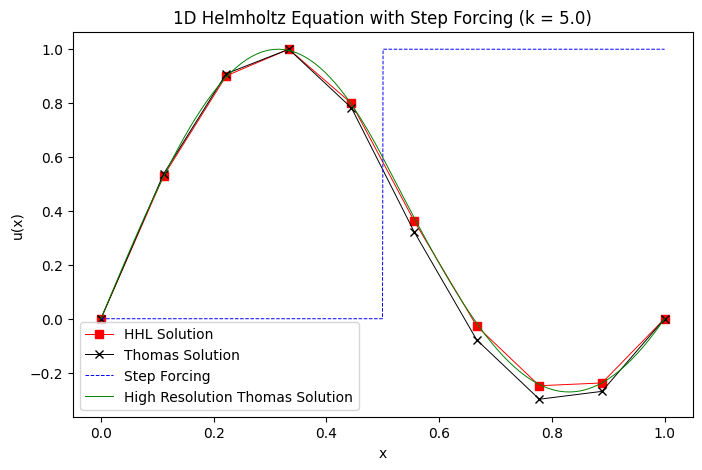

error: 13.784448694726375


In [142]:
def solve_helmholtz_step(k, num_qubits=3, L=1.0, eps=0.01, plot=True, min_scale=-1, max_scale=1):
    # --- Discretization ---
    MATRIX_SIZE = 2 ** num_qubits  # Number of interior points
    N = MATRIX_SIZE               # For clarity, N is the number of interior points
    h = L / (N + 1)               # Grid spacing

    # Interior grid points (excluding boundaries)
    x_interior = np.linspace(0, L, N + 2)[1:-1]

    # --- Build the Finite-Difference Matrix ---
    a = -2/h**2 + k**2  # main diagonal
    b = 1/h**2          # off-diagonals
    matrix = diags([b, a, b], offsets=[-1, 0, 1], shape=(N, N)).toarray()

    print('Matrix condition:', np.linalg.cond(matrix))

    # --- Define the Step Forcing Term ---
    f = np.where(x_interior < L/2, 0.0, L)

    # --- Solve using HHL ---
    tridi_mat = TridiagonalToeplitz(num_qubits, a, b)
    hhl_solver = HHL(epsilon=eps)
    hhl_solution_obj = hhl_solver.solve(tridi_mat, f)
    hhl_interior = get_solution_vector(hhl_solution_obj, hhl_solution_obj.state.num_qubits, f)
    hhl_vector = np.concatenate(([0], hhl_interior, [0]))
    hhl_sol = normalize(hhl_vector, min_scale, max_scale)

    # --- Solve using the Thomas Algorithm (Classical Solver) ---
    classical_solver = numerical_solvers()
    thomas_interior = classical_solver.solve_tridiagonal_thomas(matrix, f)
    thomas_vector = np.concatenate(([0], thomas_interior, [0]))
    thomas_sol = normalize(thomas_vector, min_scale, max_scale)

    # --- High Resolution Thomas Solver ---
    N_high_res = 100
    h_high_res = L / (N_high_res + 1)
    x_interior_high_res = np.linspace(0, L, N_high_res + 2)[1:-1]
    a_high_res = -2/h_high_res**2 + k**2
    b_high_res = 1/h_high_res**2
    matrix_high_res = diags([b_high_res, a_high_res, b_high_res], offsets=[-1, 0, 1], shape=(N_high_res, N_high_res)).toarray()
    f_high_res = np.where(x_interior_high_res < L/2, 0.0, 1.0)
    hi_thomas_interior = classical_solver.solve_tridiagonal_thomas(matrix_high_res, f_high_res)
    hi_thomas_vector = np.concatenate(([0], hi_thomas_interior, [0]))
    hi_thomas_sol = normalize(hi_thomas_vector, min_scale, max_scale)
    hi_real_domain = np.linspace(0, L, N_high_res + 2)

    # --- Optionally Plot the Solutions ---
    real_domain = np.linspace(0, L, N + 2)
    analytic_f = np.linspace(0, 1, 1000)
    f_analytic = np.where(analytic_f < L/2, 0.0, L)

    if plot:
        plt.figure(figsize=(8, 5))
        plt.plot(real_domain, hhl_sol, 'rs-', linewidth=0.7, label="HHL Solution")
        plt.plot(real_domain, thomas_sol, 'kx-', linewidth=0.7, label="Thomas Solution")
        plt.plot(analytic_f, f_analytic, 'b--', linewidth=0.7, label="Step Forcing")
        plt.plot(hi_real_domain, hi_thomas_sol, 'g-', linewidth=0.7, label="High Resolution Thomas Solution")
        plt.xlabel("x")
        plt.ylabel("u(x)")
        plt.title("1D Helmholtz Equation with Step Forcing (k = {})".format(k))
        plt.legend()
        plt.show()

    # --- Compute the Percent Difference ---
    pct_diff = np.mean(np.abs((thomas_sol[1:-1] - hhl_sol[1:-1]) / thomas_sol[1:-1])) * 100

    return real_domain, thomas_sol, hhl_sol, pct_diff

real_domain, thomas_sol, hhl_sol, pct_diff = solve_helmholtz_step(5.0, num_qubits=3, L=1.0, eps=0.01, plot=True, min_scale=-1.0, max_scale=1.0)
print('error:', pct_diff)


Accuracy decreases with high wavenumbers not able to accuately capture the large changes

### 1D Testing of the BCs
The main boundary conditions which i will be testing are the dirchlet, neumann and robin
We will be doing this for the step forcing function

In [4]:
def enforce_neumann_bcs(solution):
    """Apply Neumann BCs using ghost cell method"""
    solution[0] = solution[1]    # Left boundary
    solution[-1] = solution[-2]  # Right boundary
    return solution

def construct_neumann_matrix(N, k, h):
    """Build FD matrix for 1D Helmholtz with Neumann BCs"""
    matrix = np.zeros((N, N))
    h_sq = h**2
    
    # Main diagonal
    np.fill_diagonal(matrix, k**2 - 2/h_sq)
    
    # Off-diagonals with Neumann BC adjustments
    for i in range(N):
        if i > 0: 
            matrix[i, i-1] = 1/h_sq
        if i < N-1: 
            matrix[i, i+1] = 1/h_sq
            
    # Neumann boundary modifications
    matrix[0, 0] = k**2 - 1/h_sq    # Left boundary
    matrix[0, 1] = 1/h_sq
    matrix[-1, -1] = k**2 - 1/h_sq  # Right boundary
    matrix[-1, -2] = 1/h_sq
    
    return matrix


def solve_helmholtz_step_neumann(k, num_qubits=3, L=1.0, eps=0.01, plot=True, min_scale=-1, max_scale=1):
    # Discretization
    N = 2 ** num_qubits
    h = L / (N + 1)
    x = np.linspace(0, L, N+2)[1:-1]  # Interior points
    
    # Build Neumann matrix
    fd_matrix = construct_neumann_matrix(N, k, h)
    
    print('finite stencil: \n', fd_matrix)
    
    # Create Hermitian block matrix [[0, A], [A†, 0]]
    block_matrix = np.block([
        [np.zeros((N, N)), fd_matrix],
        [fd_matrix.T, np.zeros((N, N))]
    ])
    print('block matrix: \n', block_matrix)
    
    # Scale matrix for HHL
    max_eig = np.max(np.abs(np.linalg.eigvalsh(block_matrix)))
    scaling_factor = 0.9 / max_eig
    scaled_matrix = 1 * block_matrix
    
    # Forcing term (step function)
    f = np.where(x < L/2, 0.0, L)
    extended_f = np.concatenate([np.zeros(N), f])  # Match block structure
    
    # HHL Solve
    hhl_solver = HHL(epsilon=eps)
    hhl_solution = hhl_solver.solve(NumPyMatrix(scaled_matrix), extended_f)
    
    # Extract and process solution
    full_solution = get_solution_vector(hhl_solution, hhl_solution.state.num_qubits, 2*N)
    hhl_interior = full_solution[N:] / scaling_factor  # Undo scaling
    hhl_full = np.concatenate([[0], hhl_interior, [0]])
    hhl_full = enforce_neumann_bcs(hhl_full)
    hhl_normalized = normalize(hhl_full[::-1], min_scale, max_scale)
    print('HHL solution:', hhl_normalized)
    
    # --- Solve using the Thomas Algorithm (Classical Solver) ---
    classical_solver = numerical_solvers()  # Changed from numerical_solvers()
    thomas_interior = classical_solver.solve_tridiagonal_thomas(fd_matrix, f)  # Use original fd_matrix
    thomas_full = np.concatenate([[0], thomas_interior, [0]])
    thomas_full = enforce_neumann_bcs(thomas_full)
    thomas_normalized = normalize(thomas_full, min_scale, max_scale)

    # --- High Resolution Thomas Solver ---
    N_high_res = 100
    h_high_res = L / (N_high_res + 1)
    x_high_res = np.linspace(0, L, N_high_res + 2)
    x_interior_high_res = x_high_res[1:-1]
    
    matrix_high_res = construct_neumann_matrix(N_high_res, k, h_high_res)
    
    f_high_res = np.where(x_interior_high_res < L/2, 0.0, L)
    hi_thomas_interior = classical_solver.solve_tridiagonal_thomas(matrix_high_res, f_high_res)
    hi_thomas_full = np.concatenate([[0], hi_thomas_interior, [0]])
    hi_thomas_full = enforce_neumann_bcs(hi_thomas_full)
    hi_thomas_normalized = normalize(hi_thomas_full, min_scale, max_scale)

    # --- Plotting ---
    real_domain = np.linspace(0, L, N + 2)
    analytic_domain = np.linspace(0, L, 1000)
    f_analytic = np.where(analytic_domain < L/2, 0.0, L)

    if plot:
        plt.figure(figsize=(10, 6))
        plt.plot(real_domain, hhl_normalized, 'ro-', label='HHL Solution')
        plt.plot(real_domain, thomas_normalized, 'bx--', label='Thomas Solution')
        plt.plot(analytic_domain, f_analytic, 'g--', label='Step Forcing')
        plt.plot(x_high_res, hi_thomas_normalized, 'm-', label='High-Res Thomas')
        plt.xlabel("x")
        plt.ylabel("u(x)")
        plt.title(f"1D Helmholtz Equation with Step Forcing (k = {k})")
        plt.legend()
        plt.show()

    # --- Compute the Percent Difference ---
    pct_diff = np.mean(np.abs((thomas_normalized[1:-1] - hhl_normalized[1:-1]) / 
                             (thomas_normalized[1:-1] + 1e-8))) * 100  # Avoid division by zero

    return real_domain, thomas_normalized, hhl_normalized, pct_diff

#=======================
# Execution
#=======================

if __name__ == "__main__":
    # Example usage
    hhl_sol, thomas_sol = solve_helmholtz_step_neumann(
        k=4.0,
        num_qubits=2,  # 8 points (2^3)
        L=1.0,
        eps=0.01,
        plot=True,
        min_scale=-1,
        max_scale=1
    )

finite stencil: 
 [[ -9.  25.   0.   0.]
 [ 25. -34.  25.   0.]
 [  0.  25. -34.  25.]
 [  0.   0.  25.  -9.]]
block matrix: 
 [[  0.   0.   0.   0.  -9.  25.   0.   0.]
 [  0.   0.   0.   0.  25. -34.  25.   0.]
 [  0.   0.   0.   0.   0.  25. -34.  25.]
 [  0.   0.   0.   0.   0.   0.  25.  -9.]
 [ -9.  25.   0.   0.   0.   0.   0.   0.]
 [ 25. -34.  25.   0.   0.   0.   0.   0.]
 [  0.  25. -34.  25.   0.   0.   0.   0.]
 [  0.   0.  25.  -9.   0.   0.   0.   0.]]
hello


KeyboardInterrupt: 